C:\Users\mahmo\AppData\Local\Temp\ipykernel_11252\540807400.py:66: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


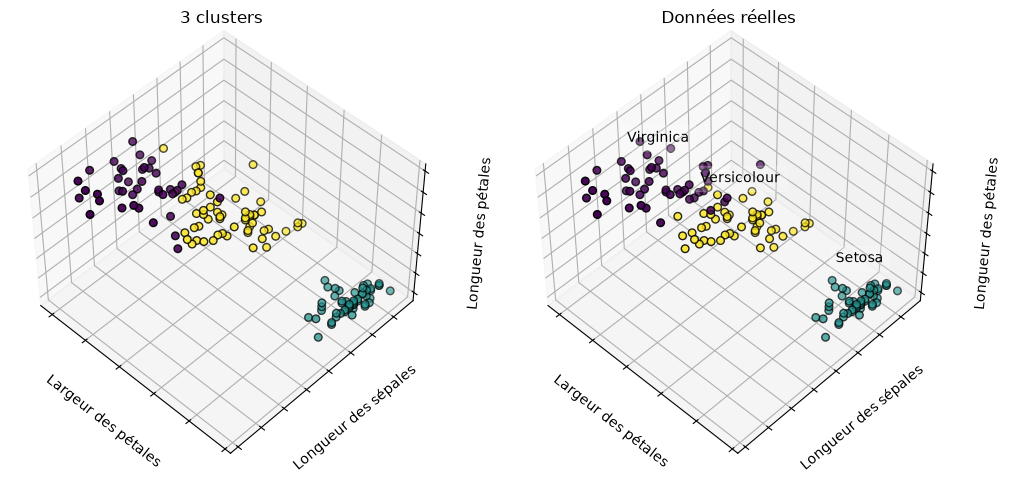

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets
from sklearn.cluster import KMeans

# 1. Chargement des données Iris
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 2. Entraînement du KMeans
estimators = [("3 clusters", KMeans(n_clusters=3, n_init="auto", random_state=42))]

# Récupération des prédictions
model = estimators[0][1]
model.fit(X)
labels = model.labels_

# 3. Création de la figure 3D côte à côte
fig = plt.figure(figsize=(12, 6))

# --- GRAPH 1 : 3 CLUSTERS (KMeans) ---
ax1 = fig.add_subplot(1, 2, 1, projection="3d", elev=48, azim=134)
# Ordre des colonnes utilisées dans l'image :
# X[:, 3] -> Largeur des pétales
# X[:, 0] -> Longueur des sépales
# X[:, 2] -> Longueur des pétales
ax1.scatter(
    X[:, 3], X[:, 0], X[:, 2], c=labels.astype(float), edgecolor="k", s=30
)

ax1.set_xlabel("Largeur des pétales")
ax1.set_ylabel("Longueur des sépales")
ax1.set_zlabel("Longueur des pétales")
ax1.set_title("3 clusters")
ax1.xaxis.set_ticklabels([])
ax1.yaxis.set_ticklabels([])
ax1.zaxis.set_ticklabels([])

# --- GRAPH 2 : DONNÉES RÉELLES ---
ax2 = fig.add_subplot(1, 2, 2, projection="3d", elev=48, azim=134)

# Annotation des noms d'espèces au milieu de leurs points
for name, label in [("Setosa", 0), ("Versicolour", 1), ("Virginica", 2)]:
    ax2.text3D(
        X[y == label, 3].mean(),
        X[y == label, 0].mean(),
        X[y == label, 2].mean() + 2,
        name,
        horizontalalignment="center",
        bbox=dict(alpha=0.2, edgecolor="w", facecolor="w"),
    )

# Re-conversion des étiquettes pour aligner la palette de couleurs du scatter
y_color = np.choose(y, [1, 2, 0]).astype(float)
ax2.scatter(X[:, 3], X[:, 0], X[:, 2], c=y_color, edgecolor="k", s=30)

ax2.set_xlabel("Largeur des pétales")
ax2.set_ylabel("Longueur des sépales")
ax2.set_zlabel("Longueur des pétales")
ax2.set_title("Données réelles")
ax2.xaxis.set_ticklabels([])
ax2.yaxis.set_ticklabels([])
ax2.zaxis.set_ticklabels([])

plt.tight_layout()
plt.show()